In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

all_records = []
offset = 0
limit = 100

while True:
    response = requests.get(
        "https://data.culture.gouv.fr/api/explore/v2.1/catalog/datasets/etablissements-cinematographiques/records",
        params={"limit": limit, "offset": offset}
    )
    data = response.json()
    results = data["results"]
    all_records.extend(results)
    
    if len(results) < limit:
        break
    offset += limit

df_cinema = pd.DataFrame(all_records)
print(df_cinema.shape)
print(df_cinema.columns.tolist())

(2061, 40)
['regioncnc', 'ndeg_auto', 'nom', 'region_administrative', 'adresse', 'code_insee', 'commune', 'population_de_la_commune', 'dep', 'ndeguu', 'unite_urbaine', 'population_unite_urbaine', 'situation_geographique', 'ecrans', 'fauteuils', 'semaines_d_activite', 'seances', 'entrees_2022', 'entrees_2021', 'evolution_entrees', 'tranche_d_entrees', 'programmateur', 'ae', 'categorie_art_et_essai', 'label_art_et_essai', 'genre', 'multiplexe', 'zone_de_la_commune', 'nombre_de_films_programmes', 'nombre_de_films_inedits', 'nombre_de_films_en_semaine_1', 'pdm_en_entrees_des_films_francais', 'pdm_en_entrees_des_films_americains', 'pdm_en_entrees_des_films_europeens', 'pdm_en_entrees_des_autres_films', 'films_art_et_essai', 'pdm_en_entrees_des_films_art_et_essai', 'latitude', 'longitude', 'geolocalisation']


In [2]:


# Vue générale
print(df_cinema.dtypes)
print("\nValeurs manquantes :")
print(df_cinema.isnull().sum().sort_values(ascending=False).head(15))

# Stats descriptives sur les variables clés
cols_numeriques = [
    'population_de_la_commune', 'entrees_2022', 'entrees_2021',
    'evolution_entrees', 'ecrans', 'fauteuils', 'seances',
    'pdm_en_entrees_des_films_art_et_essai', 'films_art_et_essai'
]
print(df_cinema[cols_numeriques].describe())

# Distribution art et essai vs non
print("\nRépartition art et essai :")
print(df_cinema['ae'].value_counts())

# Répartition par zone
print("\nRépartition par zone :")
print(df_cinema['zone_de_la_commune'].value_counts())

regioncnc                                  int64
ndeg_auto                                 object
nom                                       object
region_administrative                     object
adresse                                   object
code_insee                                object
commune                                   object
population_de_la_commune                 float64
dep                                       object
ndeguu                                    object
unite_urbaine                             object
population_unite_urbaine                 float64
situation_geographique                    object
ecrans                                   float64
fauteuils                                float64
semaines_d_activite                      float64
seances                                  float64
entrees_2022                             float64
entrees_2021                             float64
evolution_entrees                        float64
tranche_d_entrees   

In [3]:
print(df_cinema['zone_de_la_commune'].value_counts())
print("\nTotal :", df_cinema['zone_de_la_commune'].notna().sum())


zone_de_la_commune
C    902
B    559
I    336
R    264
Name: count, dtype: int64

Total : 2061


In [4]:
pd.crosstab(df_cinema['zone_de_la_commune'], df_cinema['ae'], normalize='index').mul(100).round(1)


ae,NON,OUI
zone_de_la_commune,,
B,49.4,50.6
C,34.9,65.1
I,24.1,75.9
R,47.3,52.7


 les cinémas A&E sont surreprésentés en zones rurales et intermédiaires (les seuls cinémas du coin, donc programmation variée), et sous-représentés en banlieue (multiplexes commerciaux).

Échantillon de 10 cinémas :
               nom               commune  ae
        LA LUCIOLE         Méry-sur-Oise NON
     LES TOURELLES              Vouziers OUI
        J.EUSTACHE                Pessac OUI
       L'ABREUVOIR               Salives NON
          L AIGLON              L' Aigle OUI
ESPACE PAUL VALERY    Le Plessis-Trévise NON
             C 2 L Saint-Germain-en-Laye OUI
           TRIANON              Valognes OUI
             UNION       Ars-sur-Moselle OUI
        LA COUPOLE              La Gaude OUI


Dispatch (combien par valeur) :
ae
OUI    1264
NON     797
Name: count, dtype: int64

En pourcentage :
ae
OUI    61.3 %
NON    38.7 %
Name: proportion, dtype: object

Valeurs manquantes dans 'ae' : 0


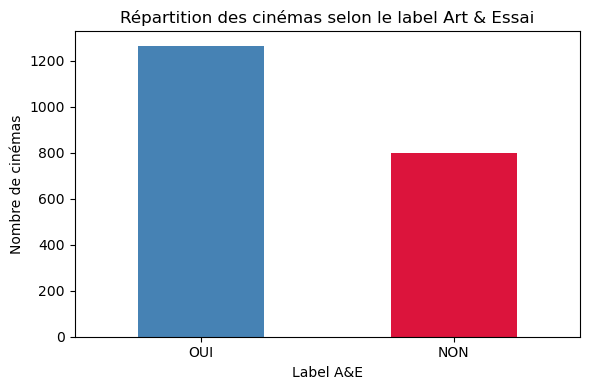

In [5]:
# Exploration  `ae` 

# 1) Un échantillon de 10 cinémas avec leur statut A&E
print("Échantillon de 10 cinémas :")
print(df_cinema[['nom', 'commune', 'ae']].sample(10, random_state=42).to_string(index=False))

# 2) Combien de cinémas pour chaque valeur ?
print("\n\nDispatch (combien par valeur) :")
print(df_cinema['ae'].value_counts())

# 3) En pourcentage
print("\nEn pourcentage :")
print(df_cinema['ae'].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')

# 4) Y a-t-il des valeurs manquantes ?
print(f"\nValeurs manquantes dans 'ae' : {df_cinema['ae'].isnull().sum()}")

# 5) Visualisation
plt.figure(figsize=(6, 4))
df_cinema['ae'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title("Répartition des cinémas selon le label Art & Essai")
plt.ylabel("Nombre de cinémas")
plt.xlabel("Label A&E")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
#Préparer les données
# 
# Objectif : prédire la colonne `ae` (OUI = A&E, NON = pas A&E)
# à partir des AUTRES caractéristiques du cinéma.

# Colonnes qu'on utilise pour prédire (les "caractéristiques")
colonnes_numeriques = [
    'pdm_en_entrees_des_films_francais',
    'pdm_en_entrees_des_films_americains',
    'pdm_en_entrees_des_films_europeens',
    'nombre_de_films_programmes',
    'nombre_de_films_inedits',
    'ecrans',
    'fauteuils',
    'entrees_2022',
    'seances',
    'population_de_la_commune',
]
colonnes_categorielles = ['multiplexe', 'zone_de_la_commune']

# X = ce qu'on regarde pour prédire
# y = ce qu'on veut prédire
X = df_cinema[colonnes_numeriques + colonnes_categorielles].copy()
y = df_cinema['ae']

# Les colonnes texte = conversion en texte

X = pd.get_dummies(X, columns=colonnes_categorielles, drop_first=False, dtype=int)


In [7]:

# ENTRAINEMENT



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=42,     
    stratify=y           
)

print(f"Entraînement : {X_train.shape[0]} cinémas")
print(f"Test         : {X_test.shape[0]} cinémas")


Entraînement : 1648 cinémas
Test         : 413 cinémas


In [8]:
# ARBRE DE DECISION
# Un arbre pose des questions successives :
#   "Plus de 40% de films américains ?"

# max_depth=4 : on limite à 4 niveaux de questions
# (sinon l'arbre devient un buisson illisible)

from sklearn.tree import DecisionTreeClassifier

arbre = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

arbre.fit(X_train, y_train)

score_train = arbre.score(X_train, y_train)
score_test = arbre.score(X_test, y_test)

print(f"Score d'entraînement : {score_train:.1%}")
print(f"Score de test        : {score_test:.1%}")


Score d'entraînement : 87.4%
Score de test        : 83.5%


[[108  52]
 [ 16 237]]


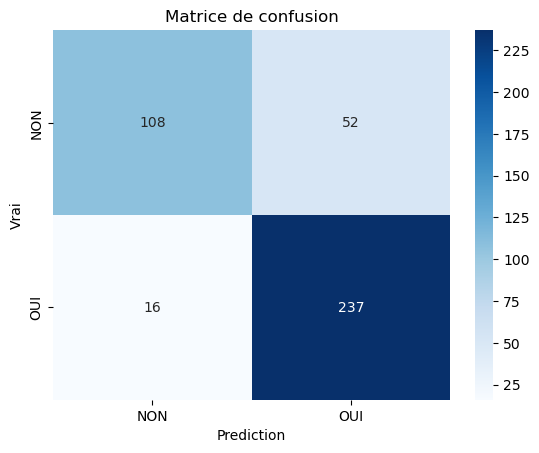

Vrais A&E bien predits : 237
Non A&E predits A&E (faux positifs) : 52
A&E rates (faux negatifs) : 16


In [9]:
# MATRICE DE CONFUSION
# Pour voir ou le modele se trompe

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# On predit sur le jeu de test
predictions = arbre.predict(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test, predictions)
print(cm)

# Version visuelle (plus jolie)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON', 'OUI'],
            yticklabels=['NON', 'OUI'])
plt.xlabel("Prediction")
plt.ylabel("Vrai")
plt.title("Matrice de confusion")
plt.show()

# Petit calcul a la main pour bien comprendre
vrai_oui = cm[1][1]
faux_oui = cm[0][1]
vrai_non = cm[0][0]
faux_non = cm[1][0]

print(f"Vrais A&E bien predits : {vrai_oui}")
print(f"Non A&E predits A&E (faux positifs) : {faux_oui}")
print(f"A&E rates (faux negatifs) : {faux_non}")


In [10]:
# REPORT
# precision, recall, f1-score

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

         NON       0.87      0.68      0.76       160
         OUI       0.82      0.94      0.87       253

    accuracy                           0.84       413
   macro avg       0.85      0.81      0.82       413
weighted avg       0.84      0.84      0.83       413



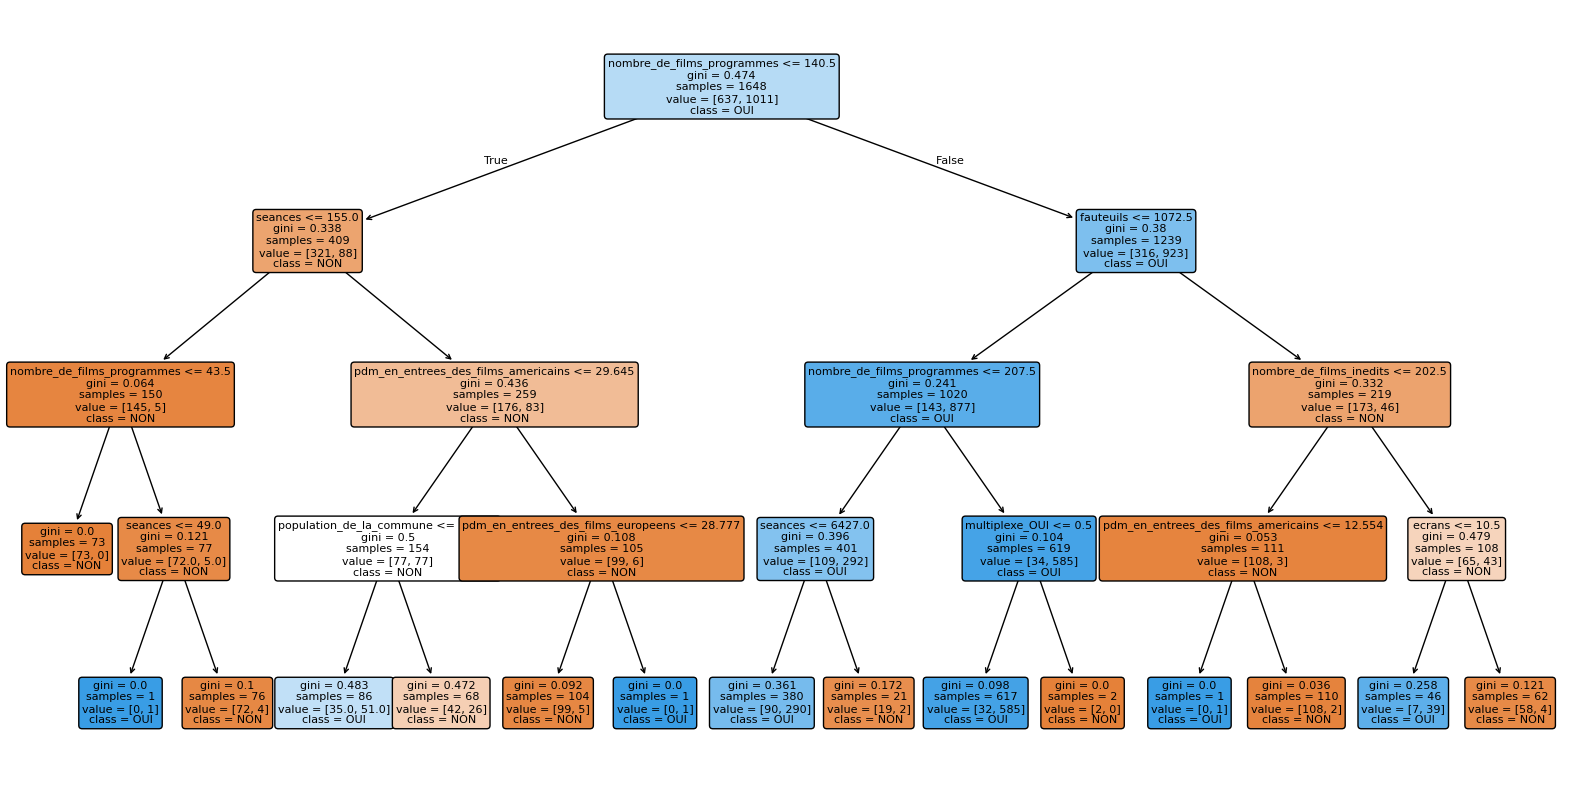

In [11]:
# VOIR L'ARBRE
# On dessine l'arbre pour voir les questions qu'il pose

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(arbre,
          feature_names=X.columns,
          class_names=arbre.classes_,
          filled=True,
          rounded=True,
          fontsize=8)
plt.show()


In [12]:
# ESSAYER UN AUTRE MODELE POUR COMPARER
# On teste une Random Forest (plein d'arbres ensemble)
# pour voir si on fait mieux

from sklearn.ensemble import RandomForestClassifier

foret = RandomForestClassifier(n_estimators=100, random_state=42)
foret.fit(X_train, y_train)

score_foret_train = foret.score(X_train, y_train)
score_foret_test = foret.score(X_test, y_test)

print(f"Arbre simple - test : {score_test:.1%}")
print(f"Random Forest - test : {score_foret_test:.1%}")

# Bon la foret fait mieux mais on perd la lisibilite de l'arbre


Arbre simple - test : 83.5%
Random Forest - test : 88.9%


In [13]:
# PREDICTION AVEC LES 2 MODELES SUR UN CINEMA FICTIF

# Je prend un cinema du test et je change les valeurs
mon_cinema = X_test.iloc[0].copy()
mon_cinema['ecrans'] = 2
mon_cinema['fauteuils'] = 150
mon_cinema['nombre_de_films_programmes'] = 200
mon_cinema['nombre_de_films_inedits'] = 150
mon_cinema['pdm_en_entrees_des_films_americains'] = 20
mon_cinema['pdm_en_entrees_des_films_francais'] = 50
mon_cinema['pdm_en_entrees_des_films_europeens'] = 25

mon_cinema_df = pd.DataFrame([mon_cinema])

# Avec l'arbre
print("Avec l'arbre :")
print(arbre.predict(mon_cinema_df))
print(arbre.predict_proba(mon_cinema_df))

# Avec la foret
print("Avec la random forest :")
print(foret.predict(mon_cinema_df))
print(foret.predict_proba(mon_cinema_df))


Avec l'arbre :
['OUI']
[[0.23684211 0.76315789]]
Avec la random forest :
['OUI']
[[0.22 0.78]]
